## Phase 2, Group 3 feature check — demographics

Checks the four demographic features built by
`src/features/build_features_demographics.py`: `age_years`, `sexo_h`/`sexo_v`,
`segmento_*` one-hot flags, and `renta_imputed`/`renta_log` (income, with a
segmento-grouped train-only median imputation and a log transform).

Three of these (age, sex, segmento) reproduce Phase 1 EDA findings on the
raw columns, same as Group 1 — a sanity check that cleaning/imputation
didn't wash out the signal. `renta`'s group-wise imputation and log
transform are new to this group, so it also gets a direct comparison of
`renta_imputed` vs. `renta_log`'s correlation with adoption.

All rates below are computed on the **train split only**, to keep val
genuinely unseen even during this kind of diagnostic look.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.append(str(Path.cwd().parent))

PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FEATURES_PATH = PROCESSED_DIR / "features_demographics.parquet"
LABELS_PATH = PROCESSED_DIR / "adoption_labels_tjcr.parquet"

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.max_columns", 50)

### Load features + adoption label, joined

`features_demographics.csv` has one row per (customer, label month);
`adoption_labels_tjcr.csv` has the `adoption` outcome for that same
(customer, month) key. Join on `(ncodpers, fecha_dato)`.

In [2]:
features = pd.read_parquet(FEATURES_PATH)

labels = pd.read_parquet(LABELS_PATH, columns=["ncodpers", "fecha_dato", "adoption"])

merged = features.merge(labels, on=["ncodpers", "fecha_dato"], how="left")
matched = merged["adoption"].notna().mean()
print(f"feature rows matched to a defined adoption label: {matched:.2%}")

train = merged[(merged["split"] == "train") & merged["adoption"].notna()].copy()
train["adoption"] = train["adoption"].astype("int8")
print(f"train rows used below: {len(train):,}")

feature rows matched to a defined adoption label: 100.00%


train rows used below: 9,446,066


In [3]:
def adoption_rate_by(df, group_col, min_count=500):
    g = df.groupby(group_col, observed=True)["adoption"].agg(["mean", "count"])
    g = g.rename(columns={"mean": "rate"})
    return g[g["count"] >= min_count].sort_index()


def print_rate(df, label=None):
    if label:
        print(f"{label}:")
    print(df.assign(rate=df["rate"].map("{:.3%}".format)))


def plot_rate_bar(rate_df, title, ax=None):
    ax = ax or plt.subplots()[1]
    rate_df["rate"].plot(kind="bar", ax=ax, color="#1f6f5c")
    ax.set_ylabel("adoption rate")
    ax.set_title(title)
    ax.yaxis.set_major_formatter(lambda y, _: f"{y:.2%}")
    plt.tight_layout()
    return ax

### Age

Phase 1 EDA (raw column): non-monotonic, peaks around 40-50.

age_years (engineered):
              rate    count
age_bucket                 
(0, 25]     0.028%  2875602
(25, 35]    0.379%  1482325
(35, 45]    1.057%  1906274
(45, 55]    1.186%  1534878
(55, 65]    0.976%   769250
(65, 100]   0.468%   877737


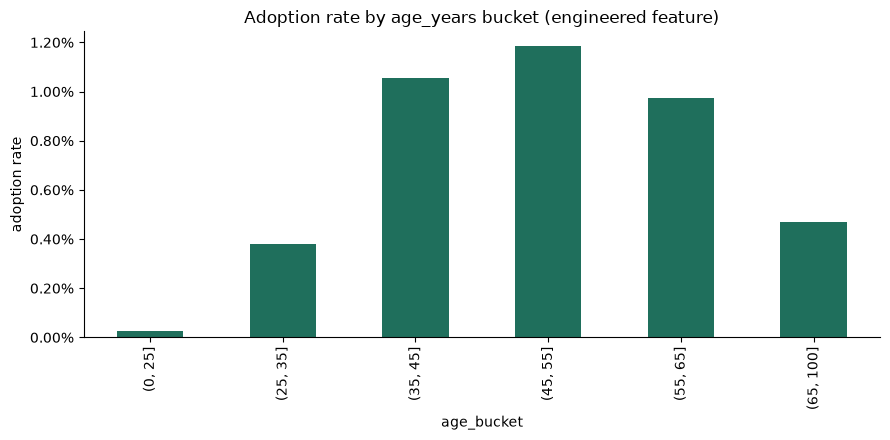

In [4]:
age_bins = [0, 25, 35, 45, 55, 65, 100]
train["age_bucket"] = pd.cut(train["age_years"], bins=age_bins)

rate_by_age = adoption_rate_by(train, "age_bucket")
print_rate(rate_by_age, "age_years (engineered)")
plot_rate_bar(rate_by_age, "Adoption rate by age_years bucket (engineered feature)")
plt.show()

### Sex

Phase 1 EDA (raw column): ~1.6x difference between sexes.

sex (engineered):
             rate    count
sex_label                 
H          0.453%  4330342
V          0.721%  5095494
missing    0.054%    20230


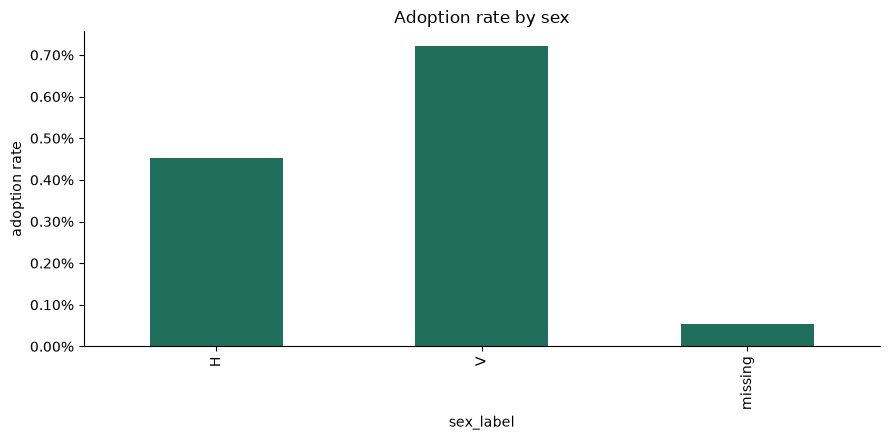

In [5]:
train["sex_label"] = train["sexo_h"].map({1: "H"}).fillna(train["sexo_v"].map({1: "V"})).fillna("missing")
rate_by_sex = adoption_rate_by(train, "sex_label")
print_rate(rate_by_sex, "sex (engineered)")
plot_rate_bar(rate_by_sex, "Adoption rate by sex")
plt.show()

### Segmento

Phase 1 EDA (raw column): TOP 3.01% vs. UNIVERSITARIO 0.09%, >30x — the
strongest single signal found in Phase 1. Reconstructing the 3-way category
from the one-hot flags (as built, not from the raw column) to check it
still holds after imputation/encoding.

segmento (engineered):
                  rate    count
segmento_label                 
missing         0.085%   147603
particulares    0.782%  5444066
top             3.074%   332852
universitario   0.098%  3521545


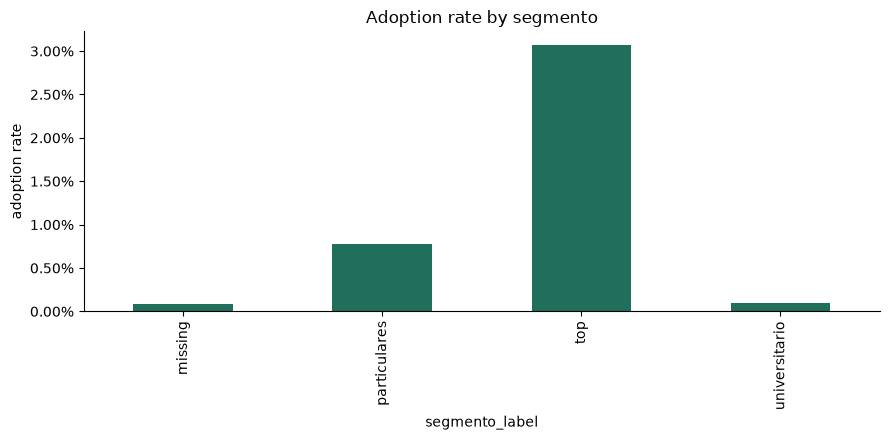

In [6]:
def segmento_label(row):
    if row["segmento_top"]:
        return "top"
    if row["segmento_particulares"]:
        return "particulares"
    if row["segmento_universitario"]:
        return "universitario"
    return "missing"


train["segmento_label"] = train.apply(segmento_label, axis=1)
rate_by_segmento = adoption_rate_by(train, "segmento_label")
print_rate(rate_by_segmento, "segmento (engineered)")
plot_rate_bar(rate_by_segmento, "Adoption rate by segmento")
plt.show()

### Income (renta)

New to this group: does the segmento-grouped median imputation preserve a
usable income signal, and does the log transform actually help?

renta_imputed quintile (engineered):
                            rate    count
renta_quintile                           
(1202.729, 67872.719]     0.387%  1889249
(67872.719, 88326.867]    0.343%  2003562
(88326.867, 107454.57]    0.592%  2018138
(107454.57, 154967.062]   0.806%  1645914
(154967.062, 28894396.0]  0.897%  1889203


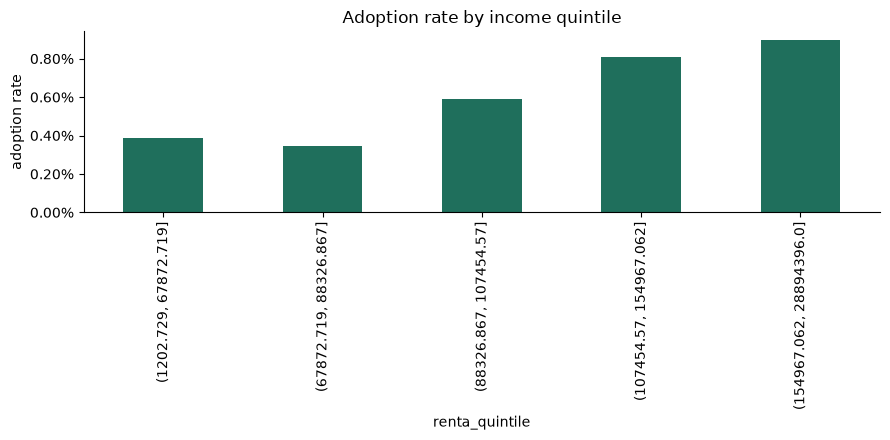

In [7]:
renta_quintile = pd.qcut(train["renta_imputed"], 5, duplicates="drop")
rate_by_renta = adoption_rate_by(train.assign(renta_quintile=renta_quintile), "renta_quintile")
print_rate(rate_by_renta, "renta_imputed quintile (engineered)")
plot_rate_bar(rate_by_renta, "Adoption rate by income quintile")
plt.show()

In [8]:
corr = train[["age_years", "renta_imputed", "renta_log", "adoption"]].corr()["adoption"].drop("adoption")
print("point-biserial correlation with adoption:")
print(corr)
print(f"\nrenta_log correlation is {corr['renta_log'] / corr['renta_imputed']:.1f}x renta_imputed's")

point-biserial correlation with adoption:
age_years        0.034953
renta_imputed    0.009179
renta_log        0.023533
Name: adoption, dtype: float64

renta_log correlation is 2.6x renta_imputed's


### Missingness recap

In [9]:
for col in ["age_missing", "sexo_missing", "segmento_missing", "renta_missing"]:
    print(f"{col} rate: {train[col].mean():.3%}")

age_missing rate: 0.309%
sexo_missing rate: 0.214%
segmento_missing rate: 1.563%
renta_missing rate: 19.314%


### Conclusion

All four demographic features reproduce the direction of their Phase 1
raw-column findings: segmento remains the strongest of the group by far
(top segment adopts several times more than universitario, echoing the >30x
spread found on the raw column), age is non-monotonic and peaks in
middle age (correlation ~0.035 — read with caution, since a linear
correlation understates a non-monotonic relationship), and sex shows the
expected small (~1.5-2x) gap. None of these individually rival
product_count_prev's ~0.163 correlation (Group 2) or even Group 1's
tenure/activity (~0.059/~0.083) — demographics are real but comparatively
weak predictors on their own, which fits Phase 1's finding that they were
the "weaker but real" signals.

The income log-transform is empirically justified, not just theoretical:
`renta_log` (~0.024) correlates noticeably more strongly with adoption
than raw `renta_imputed` (~0.009) does — about 2.6x — confirming the
right-skewed distribution was compressing the usable signal in the
untransformed feature. Both are kept in the output — `renta_log` for the
logistic regression baseline, since tree models like LightGBM are
insensitive to monotonic transforms anyway.

(Numbers as of the 2026-09-11 `/audit` eligibility-filter fix —
`docs/decisions/003-eligibility-filter.md`; all four moved only slightly
after already-holder rows were dropped from the population, unlike Group
2's product_count_prev.)

**Feature engineering (Phase 2) is now complete** across all three groups.
Next: assemble train.csv/val.csv from all three feature files plus the
label, then baseline logistic regression + LightGBM.